- General Finetune requirments: Note: This guide is designed for consumer GPUs (24GB+) like the NVIDIA RTX 4090/5090 or A10G, but can be adapted for larger systems.



https://github.com/philschmid/deep-learning-pytorch-huggingface/tree/main

The temperature parameter in language models controls how “peaked” or “flat” the probability distribution is when sampling the next token. It's applied in the softmax operation over the model’s logits. Mathematically, for each logit $$ z_i $$, the probability is computed as:

$$
P(i) = \frac{\exp\left(\frac{z_i}{T}\right)}{\sum_j \exp\left(\frac{z_j}{T}\right)}
$$

### Why Typically Use 0–1?

- **When $$T < 1$$:**  
  The differences between logits are amplified. The softmax output becomes more concentrated on the highest-probability token, making the model more deterministic (less random).
  
- **When \(T = 1\):**  
  The model uses its natural probability distribution.
  
- **When \(T > 1\):**  
  The differences between logits are diminished, which flattens the distribution. This means even lower-probability tokens have a higher chance of being selected, leading to more diverse—but sometimes less coherent—outputs.

### Concrete Example

Suppose the logits for three possible tokens are:  
$$
\mathbf{z} = [2.0, 1.0, 0.0]
$$

**With \(T = 1\):**

\[
\begin{aligned}
\exp(2.0/1) &= e^2 \approx 7.39 \\
\exp(1.0/1) &= e^1 \approx 2.72 \\
\exp(0.0/1) &= e^0 = 1
\end{aligned}
\]

Total \(= 7.39 + 2.72 + 1 \approx 11.11\)

Probabilities:
\[
\begin{aligned}
P(1) &\approx \frac{7.39}{11.11} \approx 0.665 \\
P(2) &\approx \frac{2.72}{11.11} \approx 0.245 \\
P(3) &\approx \frac{1}{11.11} \approx 0.090
\end{aligned}
\]

**With \(T = 2\):**

\[
\begin{aligned}
\exp(2.0/2) &= e^1 \approx 2.72 \\
\exp(1.0/2) &= e^{0.5} \approx 1.65 \\
\exp(0.0/2) &= e^0 = 1
\end{aligned}
\]
Total \(= 2.72 + 1.65 + 1 \approx 5.37\)

Probabilities:
\[
\begin{aligned}
P(1) &\approx \frac{2.72}{5.37} \approx 0.507 \\
P(2) &\approx \frac{1.65}{5.37} \approx 0.307 \\
P(3) &\approx \frac{1}{5.37} \approx 0.186
\end{aligned}
\]

Here you see that with \(T = 2\) (i.e. greater than 1), the highest probability token’s likelihood drops from ~66.5% to ~50.7%, and the lower-probability tokens get a boost. This makes the model’s output more varied and creative, but it can also lead to less coherent or less predictable responses.

### In Summary

- **Temperature 0–1:** Offers control to make outputs more deterministic and focused.
- **Temperature >1:** Increases randomness by `flattening the distribution`, which can be useful for creative tasks but may harm coherence.


### **Understanding Quantization in LLMs: Symmetric vs. Asymmetric**  

When large language models (LLMs) undergo **quantization**, their weights and activations are mapped from high-precision formats (like **float32**) to lower-precision ones (**float16, bfloat16, int8**) to speed up inference and reduce memory usage.  

 Types of Weight Quantization

### 1. **Post-Training Quantization (PTQ)**
- **Description**: Weights from a pre-trained model are directly converted to lower precision without retraining.
- **Advantages**: Simple and easy to implement.
- **Disadvantages**: Potential performance degradation.
- **Best Use Case**: Suitable when computational resources for retraining are limited.

### 2. **Quantization-Aware Training (QAT)**
- **Description**: Quantization is performed during training or fine-tuning, allowing the model to adapt to lower precision.
- **Advantages**: Produces better performance compared to PTQ.
- **Disadvantages**: Requires additional training data and computational resources.
- **Best Use Case**: Ideal when representativ

## Data Types in Quantization

Common floating-point formats include:
- **FP32**: 32 bits; provides high precision but requires more memory.
- **FP16 (Half-Precision)**: 16 bits; reduces memory usage but has lower precision.
- **BF16 (Brain Floating-Point)**: 16 bits; prioritizes range over precision, widely supported by modern hardware like NVIDIA Ampere GPUs.

### Comparison of FP32, FP16, and BF16
- **FP32**: High precision, high memory usage.
- **FP16/BF16**: Lower precision, reduced memory footprint. BF16 is preferred for its larger range.
- **INT8 (8-bit Integer)**:Further reduces memory footprint.

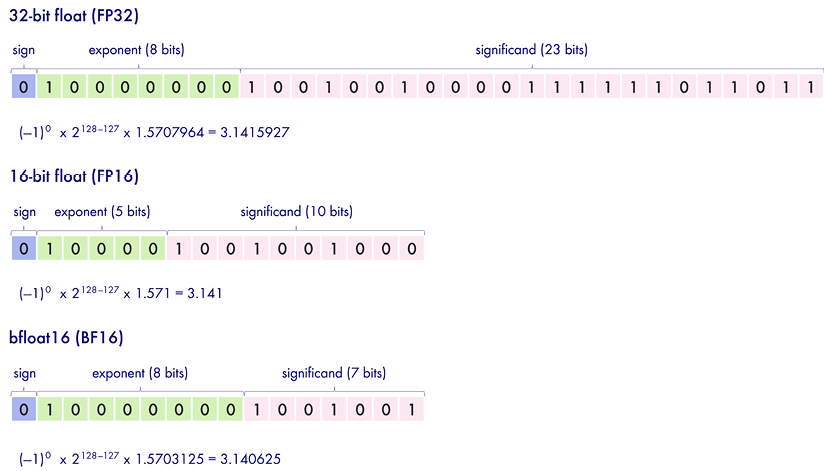


## **1️⃣ Symmetric vs. Asymmetric Quantization**
Quantization reduces precision by mapping a wide range of values into a smaller set of discrete values. The key difference between **symmetric** and **asymmetric** quantization lies in how these values are mapped.

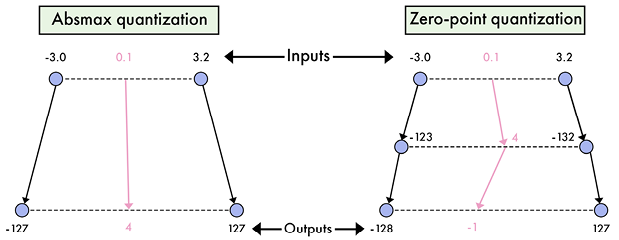 

### **🔷 Symmetric Quantization**
- The range is centered around **zero**.
- Positive and negative values are mapped **equally**.
- Represented as:  
- Used for **weight quantization** in LLMs since weights are typically **zero-mean**.
- 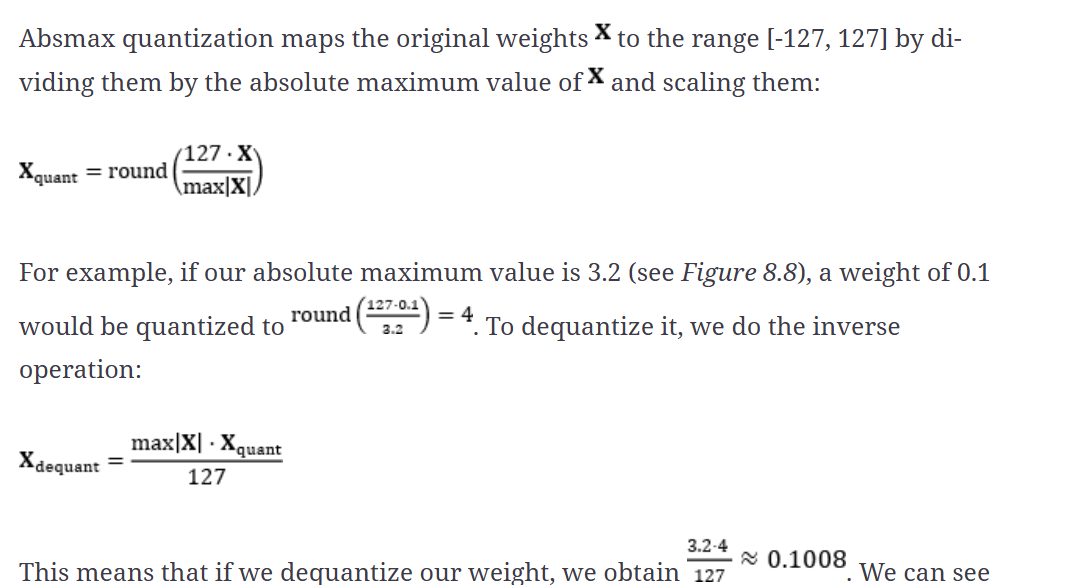
- 
✅ **Advantage**: Faster computation (hardware optimized).  
❌ **Disadvantage**: May not fully utilize the range for values that are **not zero-centered**.

- **Issue**: Smaller values (e.g., **2.38 and 34.44**) are rounded to **zero**, losing precision.

✅ **Best for**: Weight matrices in LLMs (which are zero-centered).  
❌ **Problem**: Poor representation for small-magnitude values.  


### **🔷 Asymmetric Quantization**
- Uses an **offset (zero point)** to shift the range.
- Helps in handling data with non-zero mean.
- Represented as:  
  
- Used for **activations** in LLMs, where inputs may have different dynamic ranges.
- 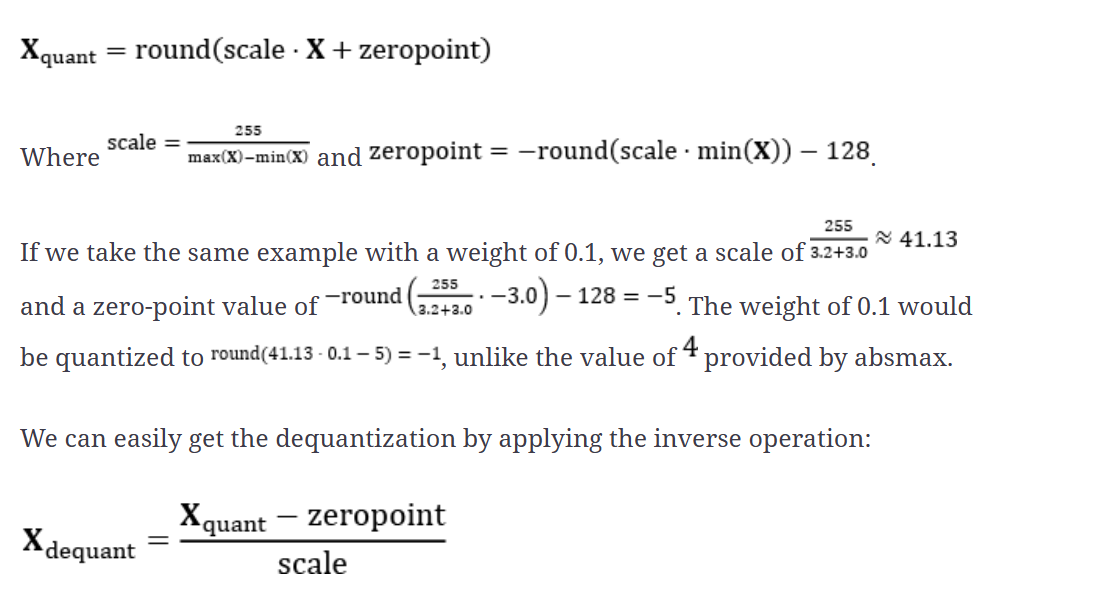

✅ **Advantage**: More efficient representation for non-zero-centered data.  
❌ **Disadvantage**: Slightly more complex computations.

---

#### **🔷 Asymmetric Quantization Results**

✅ **Best for**: Inputs/activations in LLMs (which have variable ranges).  
❌ **Problem**: Some values may shift incorrectly, causing range distortion.  

---

### **4️⃣ Conclusion**
1. **Symmetric quantization** is **simpler and faster** but loses precision for small values.  
2. **Asymmetric quantization** preserves more detail **but is more complex** and can introduce slight distortions.  
3. **In LLMs**, symmetric quantization is preferred for **weights**, while asymmetric quantization is better for **inputs/activations**.  

> `LM.int8()` employs a mixed-precision quantization scheme, `where outlier features are processed using FP16`, while the remaining values are quantized to INT8. This approach effectively reduces the memory footprint of LLMs by nearly 2x while minimizing performance degradation.
>  `NF4` is a 4-bit precision format designed for `QLoRA` (


### Quantization with GGUF and llama.cpp

#### Overview of llama.cpp
- **llama.cpp**: Open-source C++ library by Georgi Gerganov for inference with various LLMs.
- **Key Benefits**:
  - Runs on CPUs, Android devices, and general hardware (no specialized GPU needed).
  - Offloads layers to GPU to enhance speed.
  - Supports optimization techniques like FlashAttention-2 and speculative decoding.

#### GGUF Quantization Format
- **Purpose**: Simplifies and accelerates model loading for inference.
- **Supported Precision Levels**:
  - **1-Bit (IQ1_S/M)**: Low quality.
  - **2-Bit (IQ2_XXS/XS/S/M, Q2_K)**: Usable for large models, but generally low quality.
  - **3-Bit (IQ3_XXS/XS/S/M, Q3_K_S/M/L)**: Suitable for large models.
  - **4-Bit (IQ4_XS/NL, Q4_K_S/M, Q4_0/1)**: Good quality for most models.
  - **5-Bit (Q5_K_S/M, Q5_0/1)**: High quality.
  - **6-Bit (Q6_K)**: Very high quality.
  - **8-Bit (Q8_0)**: Highest quality.

#### How GGUF Works
- Values are grouped into blocks and quantized.
- **Example**:
  - Q4_0: Handles 32 values per block, scaling by the largest weight in the block.
  - Q4_K: Uses super-blocks with improved precision (e.g., scales quantized in 6 bits).
  - i-Quants: Inspired by QuIP#, balances positive/negative quant signs.

#### Practical Steps for GGUF Quantization (Example Workflow)
#### Environment Setup
1. Clone and build llama.cpp:
   ```bash
   git clone https://github.com/ggerganov/llama.cpp
   cd llama.cpp && git pull && make clean && LLAMA_CUBLAS=1 make
   pip install -r llama.cpp/requirements.txt
   ```

2. Download a model (e.g., from Hugging Face Hub):
   ```bash
   MODEL_ID="mlabonne/EvolCodeLlama-7b"
   git lfs install
   git clone https://huggingface.co/${MODEL_ID}
   ```

#### Conversion and Quantization
1. **Convert to FP16**:
   ```bash
   python llama.cpp/convert.py ${MODEL_NAME} --outtype f16 --outfile {MODEL_NAME}.fp16.bin
   ```

2. **Quantize to GGUF (e.g., Q4_K_M)**:
   ```bash
   ./llama.cpp/quantize {MODEL_NAME}.fp16.bin {MODEL_NAME}.Q4_K_M.gguf q4_k_m
   ```

#### Deployment
- Upload to Hugging Face Hub:
   ```python
   from huggingface_hub import create_repo, HfApi
   # Authenticate and upload `.gguf` files to your repository.
   ```

#### Usage
- GGUF models are compatible with:
  - **Backends**: llama-cpp-python.
  - **Frameworks**: LangChain.
  - **Frontends**: LM Studio, Text Generation Web UI.

#### Advantages of llama.cpp and GGUF
- Broad compatibility with general hardware.
- Lightweight and highly optimized for easy integration.
- Supports cutting-edge quantization techniques like FlashAttention-2.

> The  format acts as a container that efficiently stores all the crucial details of a model. Everything from the model's weights (quantized or otherwise), its architecture, and tokenizer information, to metadata like quantization parameters, model version, and usage instructions, is neatly packed into this file.



The GGUF (GGML Universal Format) is designed to store and organize important details of a machine learning model

1.  **Model Weights (Quantized or Full Precision)**
    
    -   This includes the core data tensors that the model uses for computation, such as matrices and vectors for layers, attention mechanisms, and more.
    -   The weights could be in a quantized format to save space and improve inference efficiency.
2.  **Quantization Metadata**
    
    -   Details about how the weights were quantized are stored. For example:
        -   Quantization method (e.g., per‑tensor, per‑channel, or block‑wise).
        -   Bit precision (e.g., 8‑bit, 4‑bit).
        -   Any scaling factors or zero-point values used during quantization.
3.  **Model Architecture Information**
    
    -   The layout and structure of the model are captured, such as:
        -   Number and types of layers (e.g., transformer blocks, feed-forward layers).
        -   Hyperparameters like hidden size, number of heads in attention, etc.
4.  **Tokenization Information**
    
    -   Information about the tokenizer used by the model, which includes:
        -   The vocabulary of tokens.
        -   Special tokens (e.g., start, end, padding, and unknown tokens).
        -   Byte-Pair Encoding (BPE) or other encoding rules.
5.  **Inference Parameters**
    -   Specifications that aid inference engines in handling the model:
        -   Maximum sequence length.
        -   Supported batch sizes.
        -   Computational optimizations specific to the model.
6.  **Versioning and Compatibility**
    
    -   Information about the format version (GGUF version) and compatibility notes for inference tools that load the model.
7.  **Metadata and Descriptions**
    
    -   General information such as:
        -   Model name, version, and author (if applicable).
        -   A description of what the model is designed to do.
        -   Notes about the training dataset or its intended use case.


 let’s analyze the impact of **float32, float16, bfloat16, and int8** on:  
- **Inference Time**  
- **Performance (Accuracy/Loss)**  
- **Storage Requirements**  

### **1️⃣ Model Storage Requirements**  
Llama 3.1 models have billions of parameters, and each parameter is stored in a specific precision format.  

| **Data Type** | **Bits per Parameter** | **Storage for 7B Parameters** | **Storage for 70B Parameters** |
|--------------|----------------------|-----------------------------|-----------------------------|
| **Float32**  | 32 bits (4 bytes)     | **28 GB**                   | **280 GB**                   |
| **Float16**  | 16 bits (2 bytes)     | **14 GB**                   | **140 GB**                   |
| **BFloat16** | 16 bits (2 bytes)     | **14 GB**                   | **140 GB**                   |
| **Int8**     | 8 bits (1 byte)       | **7 GB**                     | **70 GB**                     |

🔹 **Observation**:  
- **Int8 quantization reduces storage needs by 4× compared to Float32**.  
- **Float16 and Bfloat16 reduce it by 2×**, making them popular choices.  

---

### **2️⃣ Model Inference Time**  
Inference speed depends on GPU hardware and tensor precision support.  

| **Data Type** | **Relative Speed (vs. Float32)** | **Hardware Optimization** |
|--------------|---------------------------------|-------------------------|
| **Float32**  | **1× (slowest)**                | Standard GPU support    |
| **Float16**  | **2–4× faster**                 | Tensor cores optimized  |
| **BFloat16** | **2–3× faster**                 | Efficient on TPUs       |
| **Int8**     | **4–8× faster**                 | INT8 tensor cores       |

🔹 **Observation**:  
- **Float16/Bfloat16 are 2–4× faster than Float32**, commonly used in Llama models.  
- **Int8 can be up to 8× faster** but may degrade accuracy slightly.  

---

### **3️⃣ Performance (Accuracy/Loss)**  
Quantization affects model accuracy by reducing precision.  

| **Data Type** | **Accuracy Drop** | **Use Case** |
|--------------|------------------|-------------|
| **Float32**  | **0% (Full precision)** | Baseline, best accuracy |
| **Float16**  | **~0.1–0.5%** loss | Standard LLM inference |
| **BFloat16** | **~0.1–0.5%** loss | Used in TPUs, robust performance |
| **Int8**     | **~1–2% loss** | Low-latency, edge AI |

🔹 **Observation**:  
- **Float16 and Bfloat16 give near-Float32 accuracy** and are widely used in inference.  
- **Int8 may lead to noticeable performance loss** but is useful for **speed and efficiency**.  

---

### **4️⃣ Summary**
| **Metric**   | **Float32** (Baseline) | **Float16** | **BFloat16** | **Int8** |
|-------------|-----------------|----------|----------|------|
| **Storage** | 100% (Largest)   | 50%      | 50%      | 25%  |
| **Speed**   | 1× (Slow)        | 2–4×     | 2–3×     | 4–8× |
| **Accuracy**| Best (No loss)   | ~0.5% loss | ~0.5% loss | ~2% loss |

### **Final Recommendation**
- **For inference**: **Float16/Bfloat16** (good balance of speed and accuracy).  
- **For extreme efficiency**: **Int8** (best for low-memory or high-speed applications).  




### **🚀 Dot Product, Variance, and Softmax Gradients**

📌 **Key Takeaway**:

-   The variance of the dot product grows **linearly** with the dimension **d**.
-   If **d is large**, the dot product values become very spread out (high variance).

----------

### ** Softmax and Vanishing Gradients**

-   The Softmax function transforms the dot product into attention scores:
    
    Softmax(Si)= $$ eSi∑jeSj\text{Softmax}(S_i) = \frac{e^{S_i}}{\sum_j e^{S_j}} $$
-   If **d is large**, the dot product values **have high variance**, meaning:
    
    -   Some SiS_i will be **very large** →  $$ eSie^{S_i} $$ becomes **huge**.
    -   Some SiS_i will be **very small** → $$ eSie^{S_i} $$ becomes **tiny**.
    -   This makes Softmax **output close to 0 or 1** for many positions.

🎯 **Why is this bad?**

-   When Softmax outputs **extreme values (close to 0 or 1)**, the gradients of Softmax become **very small**.
-   This leads to the **vanishing gradient problem**, where the model struggles to update weights effectively.

----------

### ** Preventing the Vanishing Gradient Issue**

To control the variance, we use **scaling**:

S=q⋅kdS = \frac{q \cdot k}{\sqrt{d}}

This **reduces the variance** of SS to **1**, preventing Softmax from pushing values too far into extreme regions.
📌 **Final Insight**:
-   Without scaling, large d → large variance → **vanishing gradients**.
-   **Scaling by  $$ attention*a1/\sqrt{d} $$ stabilizes Softmax and helps learning.**

## inference frameworks, 
- Hugging Face’s Text Generation Inference (TGI), 
- vLLM, and 
- NVIDIA TensorRT-LLM.



### **1. Original Tensor**
Start with a tensor of numerical values. For example:
```
[0.1, -0.5, 3.2, -1.7, 0.0, 1.3]
```

---

### **2. Symmetric Quantization**
#### Step-by-Step Process:
1. **Find the Absolute Maximum**:  
   Identify the largest absolute value in the tensor (ignoring the sign).  
   Example:  
   - Absolute values: `[0.1, 0.5, 3.2, 1.7, 0.0, 1.3]`  
   - Absolute maximum: `3.2`

2. **Calculate the Scale**:  
   Use the formula:  
   ```
   Scale = 127 / Absolute Maximum
   ```  
   In this case:  
   ```
   Scale = 127 / 3.2 ≈ 39.6875
   ```

3. **Quantize the Values**:  
   Multiply each value in the tensor by the scale, then round to the nearest integer within the range [-127, 127].  
   Example:  
   - Scaled values: `[0.1*39.6875, -0.5*39.6875, 3.2*39.6875, ...]`  
   - Quantized values: `[4, -20, 127, -67, 0, 52]`

4. **Dequantize the Values**:  
   To approximate the original tensor, divide the quantized values by the same scale.  
   Example:  
   - Dequantized values: `[4/39.6875, -20/39.6875, 127/39.6875, ...]`  
   - Result: `[0.101, -0.504, 3.2, -1.688, 0.0, 1.309]`

---

### **3. Zero-Point Asymmetric Quantization**
#### Step-by-Step Process:
1. **Find the Range**:  
   Calculate the range of the tensor:  
   ```
   Range = Maximum Value - Minimum Value
   ```  
   Example:  
   - Max: `3.2`, Min: `-1.7`  
   - Range: `3.2 - (-1.7) = 4.9`

2. **Calculate the Scale**:  
   Use the formula:  
   ```
   Scale = Quantization Range (255) / Tensor Range
   ```  
   In this case:  
   ```
   Scale = 255 / 4.9 ≈ 52.04
   ```

3. **Determine Zero-Point**:  
   Offset values to fit the asymmetric range [-128, 127] by calculating:  
   ```
   Zero-Point = Round(-Scale * Min Value - 128)
   ```  
   Example:  
   ```
   Zero-Point = Round(-52.04 * -1.7 - 128) ≈ 64
   ```

4. **Quantize the Values**:  
   Apply the formula:  
   ```
   Quantized Value = Round(Original Value * Scale + Zero-Point)
   ```  
   Example:  
   - Quantized values: `[Round(0.1*52.04 + 64), Round(-0.5*52.04 + 64), ...]`  
   - Result: `[64, 37, 230, 9, 64, 132]`

5. **Dequantize the Values**:  
   To approximate the original tensor, use the formula:  
   ```
   Dequantized Value = (Quantized Value - Zero-Point) / Scale
   ```  
   Example:  
   - Dequantized values: `[(64-64)/52.04, (37-64)/52.04, ...]`  
   - Result: `[0.0, -0.519, 3.21, -1.689, 0.0, 1.308]`

---

### **Key Observations**
- **Absmax Quantization** is symmetric and simpler, but it may not account for distribution asymmetry.
- **Zero-Point Quantization** handles asymmetric ranges better, offering improved precision for outliers or skewed data.




### Understanding Perplexity (PPL)

Perplexity (PPL) is a metric often used in Natural Language Processing (NLP) to evaluate the effectiveness of language models. 
It is essentially a way to measure `how well a model predicts a sequence of words`.
` A lower perplexity score indicates that the language model is more adept at making accurate predictions—it is "less surprised" by the word sequences it encounters.`

#### Key Points:

1.  **Definition**:
    
    -   Perplexity is the exponentiated average negative log-likelihood of a sequence of words.
    -   Mathematically, it's defined as: $$ \text{PPL} = 2^{-\frac{1}{N} \sum_{i=1}^N \log_2 P(w_i)} $$ where ( P(w_i) ) is the probability of word ( w_i ) in the sequence.
2.  **Interpretation**:
    
    -   A lower perplexity means the model assigns higher probabilities to the actual words in the sequence.
    -   In simple terms, it means the model is more "confident" in predicting the words correctly.
3.  **Usage**:
    
    -   Perplexity is mainly used to evaluate causal language models (like GPT, Mistral), which predict the next word in a sequence.
    -   It is less relevant for Masked Language Models (MLMs) like BERT, which operate differently.
4.  **Why Perplexity?**:
    
    -   It reflects the model's ability to handle real-world language. The lower the perplexity, the better the model is at understanding and predicting text.

- **Interpretation**: A lower PPL means the model is better at predicting words in a sequence.
- **Core Idea**: Perplexity reflects how "surprised" a model is by the actual word sequence.


